# Microelectronics Cooling

We will analyze microelectronics cooling using air and determine the local heat transfer coefficient. Air is blown with a velocity $U_\infty$ and temperature $T_\infty$ over a substrate whose surface temperature is $T_\text{w}$. The air flows parallel to the substrate and makes contact with the substrate at $x=0$ and $y=0$ where the air suddenly comes to a stop (no-slip condition). For a given position $x$, we can define a thickness of the flow where the velocity varies from 0 to $U_\infty$, which we call the boundary layer thickness, $\delta$. At a position $L$, the thickness of the boundary layer can be shown to be $\delta = L / \sqrt{Re}$, where $Re$ is the Reynold's number.

We make the following assumptions:
* Incompressible flow ($\rho = \text{ constant}$).
* $\frac{dp}{dx} = 0$

With this we can write the Blasius equation: 

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0  \tag{1}$$
$$u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = \nu \frac{\partial^2 u}{\partial y ^2}  \tag{2}$$

By including the conservation of energy, we can then have the Pohlhausen equation: 

$$ \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0 $$ 
$$ u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = \nu \frac{\partial^2 u}{\partial y ^2} $$
$$ u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} = \frac{\nu}{Pr} \frac{\partial^2 T}{\partial y^2} \tag{3}$$


We can apply the following boundary conditions:
$$
\begin{rcases}
y=0, u=0, T=T_\text{w}, v=0 \\
y=\infty, u=U_\infty, T=T_\infty
\end{rcases}
\tag{4}
$$

In [2]:
#boundary layer thickness
L_cm = 1
Re = 1e4
delta_cm = L_cm / (Re**0.5); print("delta_cm=",delta_cm)

delta_cm= 0.01


Introduce a stream function (tool for 2D incompressible fluid flows):

$$
\begin{rcases}
u = \frac{\partial \psi}{\partial y} \\
v = -\frac{\partial \psi}{\partial x} 
\end{rcases}
\tag{5}
$$

Substituting equation (5) into (2):

$$\frac{\partial \psi}{\partial y} \frac{\partial^2 \psi}{\partial x \partial y} - \frac{\partial \psi}{\partial x} \frac{\partial^2 \psi}{\partial^2 y} = \nu \frac{\partial^3 \psi}{\partial y ^3} \tag{6}$$

Here are the scales:
* $L \rightarrow x$ (arbitrary ruler, not given).
* $\delta = \frac{L}{\sqrt{Re}} = \frac{L}{\sqrt{\frac{U_\infty L}{\nu}}} \rightarrow y$
* $\Psi \rightarrow \psi$

Non-dimensionalizing:
$$
\begin{rcases}
\bar{x} = \frac{x}{L} \\
\bar{y} = \frac{y}{\delta} \\
\bar{\psi} = \frac{\psi}{\Psi} \\
\end{rcases}
\tag{7}
$$

Combining equations (6) and (7):
$$\frac{\partial (\bar{\psi}\Psi)}{\partial (\bar{y} \delta)} \frac{\partial^2 (\bar{\psi}\Psi)}{\partial (\bar{x} L) \partial (\bar{y} \delta)} - \frac{\partial (\bar{\psi}\Psi)}{\partial (\bar{x} L)} \frac{\partial^2 (\bar{\psi}\Psi)}{\partial^2 (\bar{y} \delta)} = \nu \frac{\partial^3 (\bar{\psi}\Psi)}{\partial (\bar{y} \delta) ^3}$$

$$\frac{\Psi^2}{\delta^2 L} \underbrace{\frac{\partial \bar{\psi}}{\partial \bar{y}} \frac{\partial^2 \bar{\psi}}{\partial \bar{x} \partial \bar{y}}}_{\mathcal{O}(1)} - 
 \frac{\Psi^2}{L \delta^2}   \underbrace{\frac{\partial \bar{\psi}}{\partial \bar{x}}         \frac{\partial^2 \bar{\psi}}{\partial^2 \bar{y} }}_{\mathcal{O}(1)} = \frac{\nu \Psi}{\delta^3} \underbrace{\frac{\partial^3 \bar{\psi}}{\partial \bar{y}  ^3}}_{\mathcal{O}(1)} \tag{8}$$

B.L. statement:

$$\frac{\Psi^2}{\delta^2 L} = \frac{\nu \Psi}{\delta^3} \implies \Psi = \frac{\nu L }{\delta} \implies \Psi = \frac{\nu L }{\frac{L}{\sqrt{\frac{U_\infty L}{\nu}}}} = \sqrt{\nu U_\infty L} \tag{9}$$

We can now write the dimensionless equations as:
$$\frac{\partial \bar{\psi}}{\partial \bar{y}} \frac{\partial^2 \bar{\psi}}{\partial \bar{x} \partial \bar{y}} - 
 \frac{\partial \bar{\psi}}{\partial \bar{x}}         \frac{\partial^2 \bar{\psi}}{\partial^2 \bar{y} } = \frac{\partial^3 \bar{\psi}}{\partial \bar{y}  ^3} \tag{10}$$

The boundary conditions then become:
$$
\begin{rcases}
\bar{y}=0, \frac{\partial \bar{\psi}}{\partial \bar{y}}=0,  \frac{\partial \psi}{\partial x}=0 \\
\bar{y}=\infty, \frac{\partial \bar{\psi}}{\partial \bar{y}} = 1
\end{rcases}
\tag{11}
$$

We know that:
$$\bar{\psi} = f(\bar{x},\bar{y}) $$

We can try to guess the form of the function:

$$\bar{\psi} \stackrel{?}{=} \bar{x} + \bar{y} $$

$$\frac{\psi}{\Psi} = \frac{x}{L} + \frac{y}{\delta} $$

$$\psi = \underbrace{\sqrt{\nu U_\infty L} \frac{x}{L}}_\text{will not work because ``L'' does not disappear} + \sqrt{\nu U_\infty L} \frac{y}{\frac{L}{\sqrt{\frac{U_\infty L}{\nu}}}} $$

$L$ should be automatically eliminated. We can try again:

$$\bar{\psi} = f \left( \frac{\bar{y}}{\sqrt{\bar{x}}} \right) \cdot \sqrt{\bar{x}} $$

$$\frac{\psi}{\Psi} = \sqrt{\frac{x}{L}} f \left( \frac{\frac{y}{\frac{L}{\sqrt{\frac{U_\infty L}{\nu}}}}}{\sqrt{\frac{x}{L}}} \right) $$

$$\psi = \sqrt{\nu U_\infty L}  \sqrt{\frac{x}{L}} f \left( \frac{\frac{y}{\frac{L}{\sqrt{\frac{U_\infty L}{\nu}}}}}{\sqrt{\frac{x}{L}}} \right) $$

$$\psi = \sqrt{\nu U_\infty x} f \left(y \sqrt{\frac{U_\infty}{\nu x}} \right) $$

$$\boxed{\psi = \sqrt{\nu U_\infty x} f \left(\eta \right), \eta = y \sqrt{\frac{U_\infty}{\nu x}} }$$

This is self-similar as a result of group theory. We can write the velocity as:

$$u = \frac{\partial \left( \psi \right)}{\partial \left( y \right)} = \frac{\partial \left( \sqrt{\nu U_\infty x} f \left(\eta \right) \right)}{\partial \left( \frac{\eta}{\sqrt{\frac{U_\infty}{\nu x}}} \right)}$$

$$u = U_\infty \frac{\partial f }{\partial \eta} \implies u = U_\infty \frac{d f }{d \eta} = U_\infty f' \tag{12}$$

Recalling equation (2) and its boundary conditions, we can write:
$$\implies 
\begin{rcases}
f'' + \frac{1}{2}f f'' = 0\\
\eta = 0, f = f' = 0\\
\eta = \infty, f' = 1
\end{rcases}
\text{solved in 1908 numerically} \tag{13}
$$

The wall shear stress can be written as:
$$\tau_\text{w} = \mu \frac{\partial u}{\partial y} |_{y=0} \sim f''(0) \tag{14}$$

This solution was thought to be useful for flight...usually this equation is only good for $L\sim10$cm. Its application is important for chip cooling. Turbulent friction is much higher so it was easy to find areas on a wing where the flow was turbulent because it would be warmer. Areas of laminar friction were much cooler. That was top secret during WWII.

Computed f''(0) = 0.33206


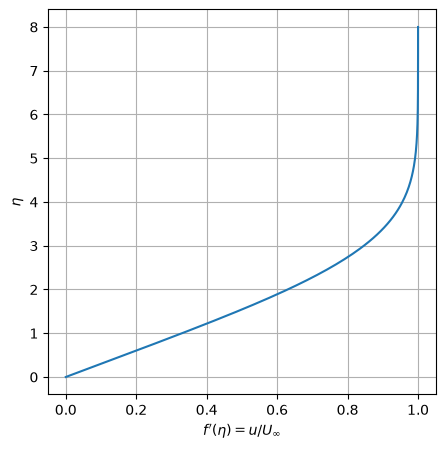

In [12]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

def blasius_rhs(eta, y):
    """
    Converts 3rd-order Blasius ODE into a system of 1st-order ODEs:
    y[0] = f
    y[1] = f'
    y[2] = f''
    """
    f, df, d2f = y
    return [df, d2f, -0.5 * f * d2f]

def objective(alpha, eta_max=10.0):
    """
    Shooting target function: Integrates IVP from eta=0 to eta_max
    given guess alpha = f''(0), returning error in boundary condition f'(eta_max) = 1.
    """
    sol = solve_ivp(
        blasius_rhs, 
        [0, eta_max], 
        [0.0, 0.0, alpha], 
        method='RK45', 
        rtol=1e-8, 
        atol=1e-10
    )
    # Target: f'(eta_max) - 1 = 0
    return sol.y[1, -1] - 1.0

# Solve for unknown initial condition f''(0)
eta_far = 10.0  # Approximates infinity
sol_root = root_scalar(objective, args=(eta_far,), bracket=[0.1, 1.0], method='brentq')
alpha_optimal = sol_root.root

# Generate full solution profile using optimal f''(0)
eta_eval = np.linspace(0, 8, 200)
solution = solve_ivp(
    blasius_rhs, 
    [0, 8], 
    [0.0, 0.0, alpha_optimal], 
    t_eval=eta_eval,
    rtol=1e-8, 
    atol=1e-10
)

f = solution.y[0]
df = solution.y[1]   # Dimensionless velocity u/U_inf
d2f = solution.y[2]  # Shear stress profile

print(f"Computed f''(0) = {alpha_optimal:.5f}")

# Plotting profiles
plt.figure(figsize=(5, 5))
plt.plot(df, solution.t)
plt.ylabel("$\eta$")
plt.xlabel("$f'(\\eta) = u/U_\\infty$")
plt.grid(True)
# plt.legend()
plt.savefig("blasius.pdf")
plt.show()

We can non-dimensionalize temperature:

$$ \theta = \frac{T - T_\text{w}}{T_\infty - T_\text{w}}$$
$$ y = 0, \theta = 0$$
$$ y = \infty, \theta = 1$$

$$\theta = \theta(\eta)$$

After some work, 

$$
\begin{rcases}
\theta'' + \frac{Pr}{2}\theta' f = 0 \\
\eta = 0, \theta = 0 \\
\eta = \infty, \theta = 1
\end{rcases}
\tag{16}
$$

If $u = f'$. Then:

$$u'' + \frac{1}{2}fu' = 0 $$
$$\eta = 0, u = 0$$
$$ \eta = \infty, u = \infty$$

So, for $Pr=1$, $\theta = f'$. In general,
$$\theta = \frac{\int_0^\eta \exp \left(-\frac{Pr}{2} \int_0^\eta f(\xi) d\xi \right) d\xi}{\int_0^\infty \exp \left[-\frac{Pr}{2} \int_0^\eta f(\xi) d\xi \right] d\xi} \tag{17}$$

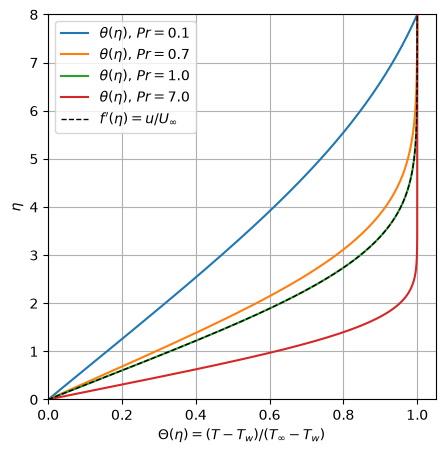

In [26]:
from scipy.integrate import cumulative_trapezoid

# Prandtl numbers relevant to thermal management (e.g., liquid cooling, air)
prandtl_numbers = [0.1, 0.7, 1.0, 7.0]

plt.figure(figsize=(5, 5))

for Pr in prandtl_numbers:
    # 1. Inner integral: int_0^\eta f(\xi) d\xi
    inner_int = cumulative_trapezoid(f, solution.t, initial=0)
    
    # 2. Integrand: exp(-Pr/2 * inner_int)
    integrand = np.exp(-0.5 * Pr * inner_int)
    
    # 3. Outer integral and normalization: int_0^\eta integrand d\xi / int_0^\infty integrand d\xi
    theta_num = cumulative_trapezoid(integrand, solution.t, initial=0)
    theta = theta_num / theta_num[-1]
    
    plt.plot(theta, solution.t, label=f"$\\theta(\\eta)$, $Pr = {Pr}$")

# Plot normalized velocity profile f'(eta) for reference
plt.plot(df, solution.t, 'k--', linewidth=1, label="$f'(\\eta) = u/U_\infty$")

plt.ylabel("$\eta$")
plt.xlabel("$ \Theta(\eta) = (T - T_w)/(T_\infty - T_w)$")
plt.ylim([0, 8])
plt.xlim([0, 1.05])
plt.grid(True)
plt.legend()
plt.savefig("pohlhausen.pdf")
plt.show()

The higher the slope at zero, the higher the heat transfer. 

* $Pr<1 \rightarrow \delta_T > \delta_L \rightarrow$ liquid metals (high $\alpha$).
* $Pr>1 \rightarrow \delta_T < \delta_L \rightarrow$ oils (low $\alpha$).

$$ q = + k \frac{\partial T}{\partial y}|_{y=0} = + k \frac{\partial (T - T_\text{w})}{\partial y}|_{y=0} = + k (T_\infty - T_\text{w}) \frac{\partial \theta}{\partial y}|_{y=0}$$

$$ q = + k (T_\infty - T_\text{w}) \frac{d \theta}{d \eta}|_{\eta=0} \sqrt{\frac{U_\infty}{\nu x}} \tag{18}$$

$\theta'(0)$ is an important calculated parameter. Recall Newton's cooling law:

$$ q = h (T_\infty - T_\text{w}) \tag{19}$$

Equating equations (18) and (19):

$$h (T_\infty - T_\text{w}) = + k (T_\infty - T_\text{w}) \frac{d \theta}{d \eta}|_{\eta=0} \sqrt{\frac{U_\infty}{\nu x}}$$

$$h = k \theta'(0) \sqrt{\frac{U_\infty}{\nu x}} \implies \underbrace{\frac{h x}{k}}_{Nu_x} = \theta'(0) \underbrace{\sqrt{\frac{U_\infty x}{\nu}}}_{\sqrt{Re_x}}$$

$$ \boxed{Nu_x = \theta'(0) \sqrt{Re_x}}$$